# **PART I**

# **Importing libraries**

In [260]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

# **Stocks and EMA calculation**

In [261]:
tickers = ['ADANIGREEN.NS', 'BEL.NS']
start_date = '2024-05-22'
end_date = '2025-05-22'

adani = yf.download(tickers[0], start=start_date, end=end_date, interval="1d")
bharat = yf.download(tickers[1], start=start_date, end=end_date,interval="1d")
adani.columns = adani.columns.get_level_values(0)
bharat.columns = bharat.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [262]:
print(adani.head())
print(bharat.head())

Price             Close         High          Low         Open   Volume
Date                                                                   
2024-05-22  1866.449951  1898.000000  1860.000000  1879.000000   578311
2024-05-23  1888.800049  1909.000000  1845.550049  1870.000000  3893291
2024-05-24  1926.650024  1949.000000  1889.050049  1898.800049  2928305
2024-05-27  1929.500000  1958.800049  1891.000000  1943.699951  4354846
2024-05-28  1893.650024  1935.000000  1865.150024  1935.000000  1846867
Price            Close        High         Low        Open    Volume
Date                                                                
2024-05-22  281.276062  282.168681  262.134197  274.730139  85801218
2024-05-23  286.135895  290.896549  280.879338  283.953911  70631009
2024-05-24  294.764587  297.442444  283.656354  285.639965  63609206
2024-05-27  292.037170  300.715469  287.276485  299.277339  49890427
2024-05-28  286.730988  293.326488  282.714157  293.276910  33893805


In [263]:
adani['EMA'] = adani["Close"].ewm(span=14, adjust=False).mean()
print(adani)
print("\n\n")
bharat['EMA'] = bharat["Close"].ewm(span=14, adjust=False).mean()
print(bharat)

Price             Close         High          Low         Open   Volume  \
Date                                                                      
2024-05-22  1866.449951  1898.000000  1860.000000  1879.000000   578311   
2024-05-23  1888.800049  1909.000000  1845.550049  1870.000000  3893291   
2024-05-24  1926.650024  1949.000000  1889.050049  1898.800049  2928305   
2024-05-27  1929.500000  1958.800049  1891.000000  1943.699951  4354846   
2024-05-28  1893.650024  1935.000000  1865.150024  1935.000000  1846867   
...                 ...          ...          ...          ...      ...   
2025-05-15   967.900024   972.799988   953.400024   972.099976  4951675   
2025-05-16  1020.099976  1025.000000   965.200012   971.450012  7644511   
2025-05-19  1014.000000  1038.349976  1010.049988  1031.949951  3176879   
2025-05-20   983.950012  1020.950012   981.799988  1016.000000  2713486   
2025-05-21   996.500000  1003.000000   977.200012   985.000000  2228757   

Price               EMA 

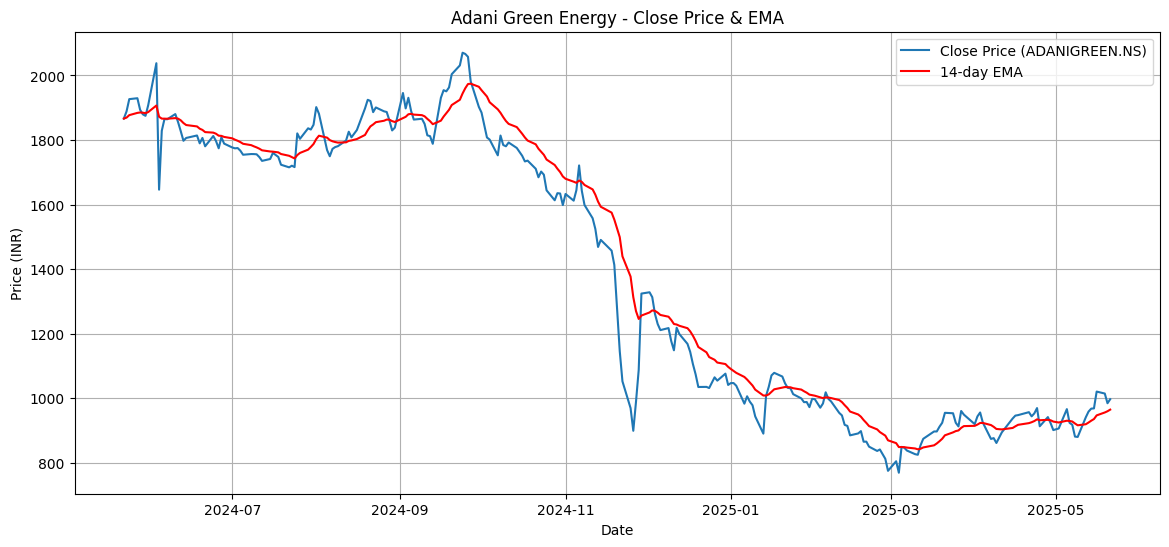

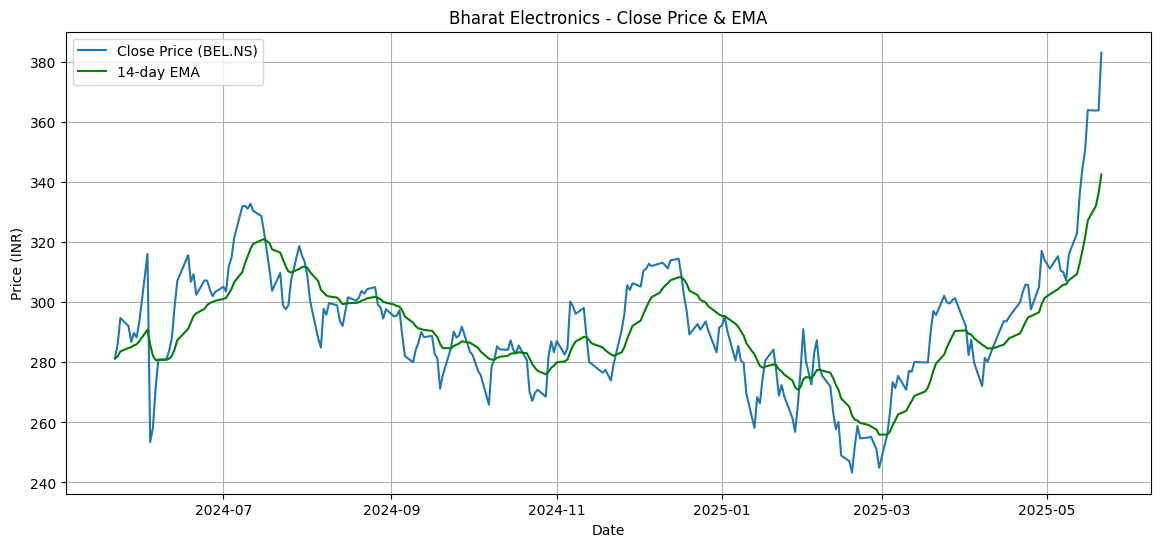

In [264]:
plt.figure(figsize=(14, 6))
plt.plot(adani.index, adani["Close"], label='Close Price (ADANIGREEN.NS)')
plt.plot(adani.index, adani['EMA'], label='14-day EMA', color='red')
plt.title('Adani Green Energy - Close Price & EMA')
plt.xlabel("Date")
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(bharat.index, bharat["Close"], label='Close Price (BEL.NS)')
plt.plot(bharat.index, bharat['EMA'], label='14-day EMA', color='green')
plt.title('Bharat Electronics - Close Price & EMA')
plt.xlabel("Date")
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

# **Strategy 1: Basic EMA Crossover Strategy**
 Buy Signal: Current close > EMA & Previous close < Previous EMA

Sell Signal: Current close < EMA & Previous close > Previous EMA

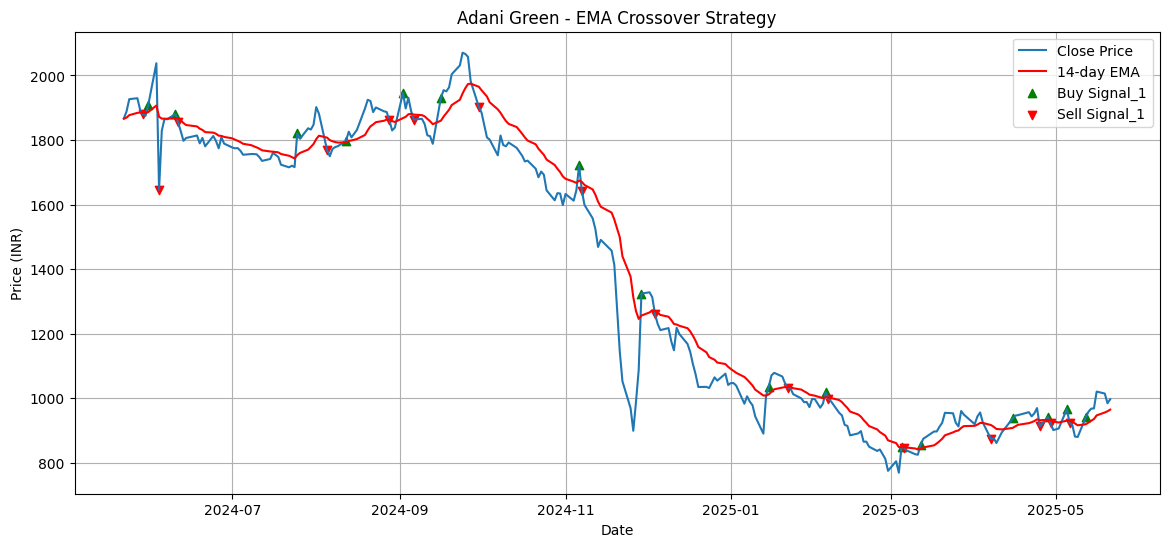

In [265]:
adani['Prev_Close'] = adani["Close"].shift(1)
adani['Prev_EMA'] = adani['EMA'].shift(1)

# Create signal column
adani['Signal_1'] = 0

adani.loc[(adani["Close"] > adani['EMA']) & (adani['Prev_Close'] < adani['Prev_EMA']), 'Signal_1'] = 1
adani.loc[(adani["Close"] < adani['EMA']) & (adani['Prev_Close'] > adani['Prev_EMA']), 'Signal_1'] = -1

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(adani.index, adani["Close"], label='Close Price')
plt.plot(adani.index, adani['EMA'], label='14-day EMA', color='red')
plt.scatter(adani[adani['Signal_1'] == 1].index, adani[adani['Signal_1'] == 1]["Close"], label='Buy Signal_1', marker='^', color='green')
plt.scatter(adani[adani['Signal_1'] == -1].index, adani[adani['Signal_1'] == -1]["Close"], label='Sell Signal_1', marker='v', color='red')
plt.title('Adani Green - EMA Crossover Strategy')
plt.xlabel("Date")
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

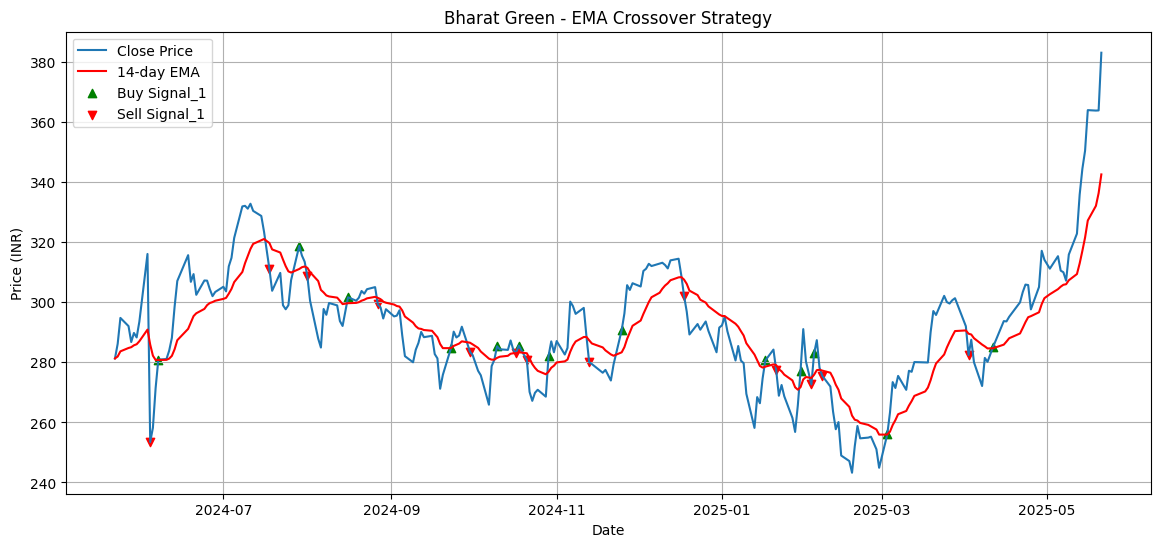

In [266]:
bharat['Prev_Close'] = bharat["Close"].shift(1)
bharat['Prev_EMA'] = bharat['EMA'].shift(1)

# Create Signal column
bharat['Signal_1'] = 0

bharat.loc[(bharat["Close"] > bharat['EMA']) & (bharat['Prev_Close'] < bharat['Prev_EMA']), 'Signal_1'] = 1
bharat.loc[(bharat["Close"] < bharat['EMA']) & (bharat['Prev_Close'] > bharat['Prev_EMA']), 'Signal_1'] = -1

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(bharat.index, bharat["Close"], label='Close Price')
plt.plot(bharat.index, bharat['EMA'], label='14-day EMA', color='red')
plt.scatter(bharat[bharat['Signal_1'] == 1].index, bharat[bharat['Signal_1'] == 1]["Close"], label='Buy Signal_1', marker='^', color='green')
plt.scatter(bharat[bharat['Signal_1'] == -1].index, bharat[bharat['Signal_1'] == -1]["Close"], label='Sell Signal_1', marker='v', color='red')
plt.title('Bharat Green - EMA Crossover Strategy')
plt.xlabel("Date")
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

# **Strategy 2: EMA Strategy with Dynamic ATR Band**
Upper Band = EMA + (Current High - Current Low)

Lower Band = EMA - (Current High - Current Low)

* Buy Signal: Price > Upper Band
* Sell Signal: Price < Lower Band

In [267]:
adani['Upper_Band'] = adani['EMA'] + adani['High'] - adani['Low']
adani['Lower_Band'] = adani['EMA'] - adani['High'] + adani['Low']
bharat['Upper_Band'] = bharat['EMA'] + bharat['High'] - bharat['Low']
bharat['Lower_Band'] = bharat['EMA'] - bharat['High'] + bharat['Low']

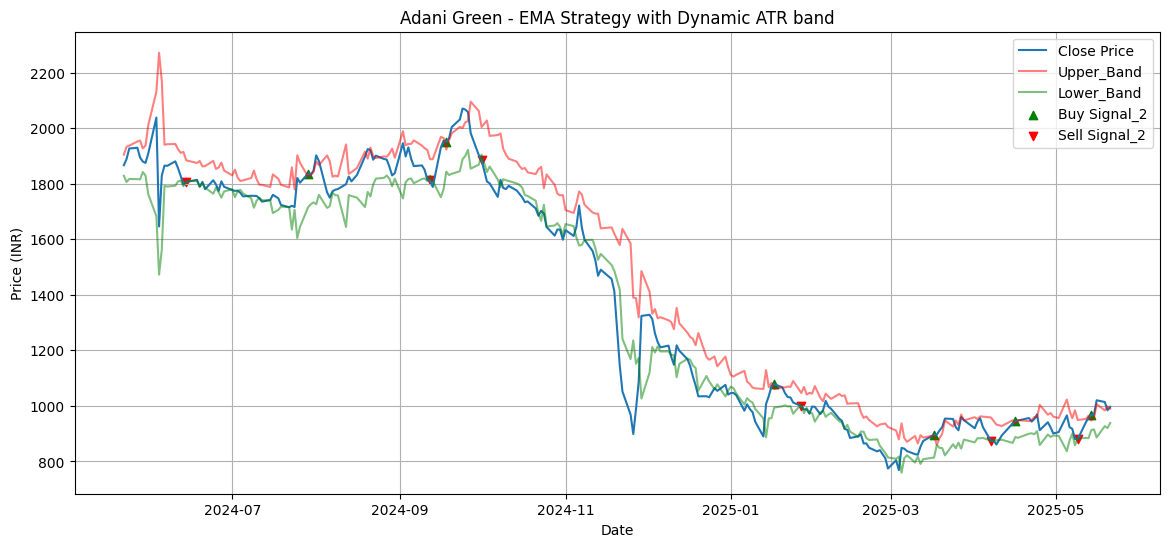

In [268]:
adani['Signal_2'] = 0

adani.loc[(adani["Close"] > adani['Upper_Band']), 'Signal_2'] = 1
adani.loc[(adani["Close"] < adani['Lower_Band']), 'Signal_2'] = -1

last_signal = 0
for i in range(len(adani)):
    current = adani.loc[adani.index[i], 'Signal_2']
    if current != 0:
        if current == last_signal:
            adani.loc[adani.index[i], 'Signal_2'] = 0
        else:
            last_signal = current

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(adani.index, adani["Close"], label='Close Price')
plt.plot(adani.index, adani['Upper_Band'], label='Upper_Band', color='red',alpha=0.5)
plt.plot(adani.index, adani['Lower_Band'], label='Lower_Band', color='green',alpha =0.5)
plt.scatter(adani[adani['Signal_2'] == 1].index, adani[adani['Signal_2'] == 1]["Close"], label='Buy Signal_2', marker='^', color='green')
plt.scatter(adani[adani['Signal_2'] == -1].index, adani[adani['Signal_2'] == -1]["Close"], label='Sell Signal_2', marker='v', color='red')
plt.title('Adani Green - EMA Strategy with Dynamic ATR band')
plt.xlabel("Date")
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

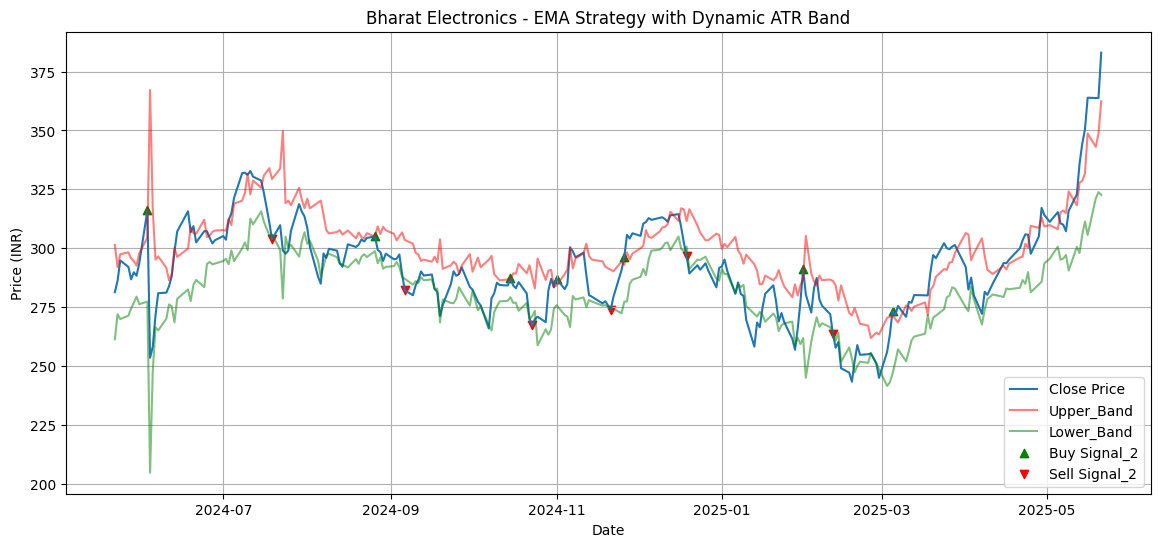

In [269]:
bharat['Signal_2'] = 0
bharat.loc[bharat["Close"] > bharat['Upper_Band'], 'Signal_2'] = 1
bharat.loc[bharat["Close"] < bharat['Lower_Band'], 'Signal_2'] = -1

last_signal = 0
for i in range(len(bharat)):
    current = bharat.loc[bharat.index[i], 'Signal_2']
    if current != 0:
        if current == last_signal:
            bharat.loc[bharat.index[i], 'Signal_2'] = 0
        else:
            last_signal = current

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(bharat.index, bharat["Close"], label='Close Price')
plt.plot(bharat.index, bharat['Upper_Band'], label='Upper_Band', color='red', alpha=0.5)
plt.plot(bharat.index, bharat['Lower_Band'], label='Lower_Band', color='green', alpha=0.5)
plt.scatter(bharat[bharat['Signal_2'] == 1].index, bharat[bharat['Signal_2'] == 1]["Close"], label='Buy Signal_2', marker='^', color='green')
plt.scatter(bharat[bharat['Signal_2'] == -1].index, bharat[bharat['Signal_2'] == -1]["Close"], label='Sell Signal_2', marker='v', color='red')
plt.title('Bharat Electronics - EMA Strategy with Dynamic ATR Band')
plt.xlabel("Date")
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()


# **Strategy 3: ATR Breakout Strategy**

In [270]:
high_low_a = adani['High'] - adani['Low']
high_close_prev_a = abs(adani['High'] - adani["Close"].shift(1))
low_close_prev_a = abs(adani['Low'] - adani["Close"].shift(1))

adani['True_Range'] = pd.concat([high_low_a, high_close_prev_a, low_close_prev_a], axis=1).max(axis=1)

adani['ATR'] = adani['True_Range'].ewm(span=14, adjust=False).mean()


In [271]:
high_low_b = bharat['High'] - bharat['Low']
high_close_prev_b = abs(bharat['High'] - bharat["Close"].shift(1))
low_close_prev_b = abs(bharat['Low'] - bharat["Close"].shift(1))

bharat['True_Range'] = pd.concat([high_low_b, high_close_prev_b, low_close_prev_b], axis=1).max(axis=1)

bharat['ATR'] = bharat['True_Range'].ewm(span=14, adjust=False).mean()


In [272]:
k = 1.5
adani['Upper_Band_ATR'] = adani['EMA'] + k * adani['ATR']
adani['Lower_Band_ATR'] = adani['EMA'] - k * adani['ATR']
bharat['Upper_Band_ATR'] = bharat['EMA'] + k * bharat['ATR']
bharat['Lower_Band_ATR'] = bharat['EMA'] - k * bharat['ATR']

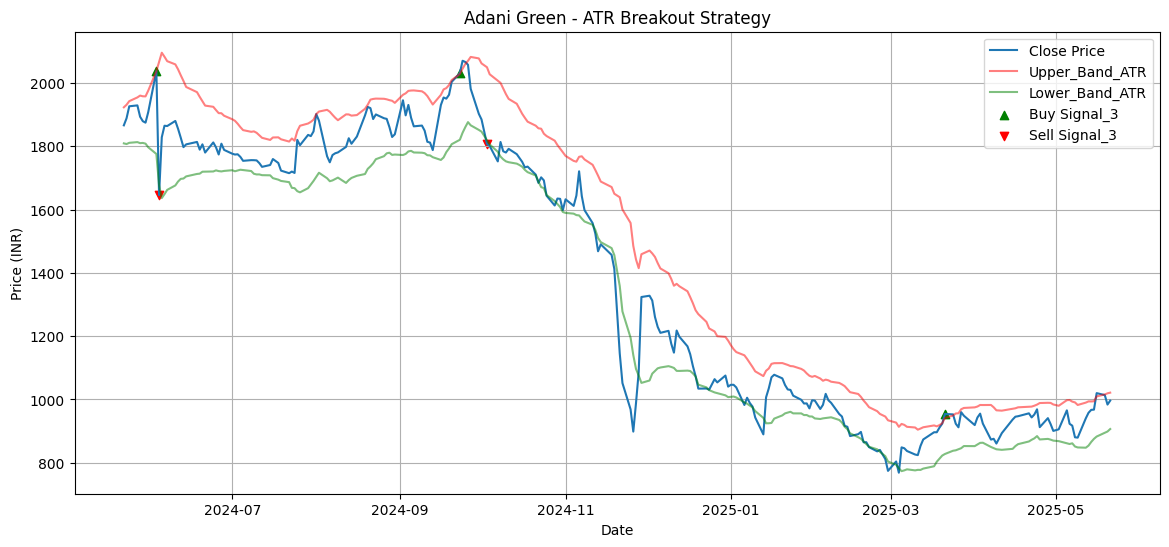

In [273]:
adani['Signal_3'] = 0

adani.loc[(adani["Close"] > adani['Upper_Band_ATR']), 'Signal_3'] = 1
adani.loc[(adani["Close"] < adani['Lower_Band_ATR']), 'Signal_3'] = -1

last_signal = 0
for i in range(len(adani)):
    current = adani.loc[adani.index[i], 'Signal_3']
    if current != 0:
        if current == last_signal:
            adani.loc[adani.index[i], 'Signal_3'] = 0
        else:
            last_signal = current

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(adani.index, adani["Close"], label='Close Price')
plt.plot(adani.index, adani['Upper_Band_ATR'], label='Upper_Band_ATR', color='red',alpha=0.5)
plt.plot(adani.index, adani['Lower_Band_ATR'], label='Lower_Band_ATR', color='green',alpha =0.5)
plt.scatter(adani[adani['Signal_3'] == 1].index, adani[adani['Signal_3'] == 1]["Close"], label='Buy Signal_3', marker='^', color='green')
plt.scatter(adani[adani['Signal_3'] == -1].index, adani[adani['Signal_3'] == -1]["Close"], label='Sell Signal_3', marker='v', color='red')
plt.title('Adani Green - ATR Breakout Strategy')
plt.xlabel("Date")
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

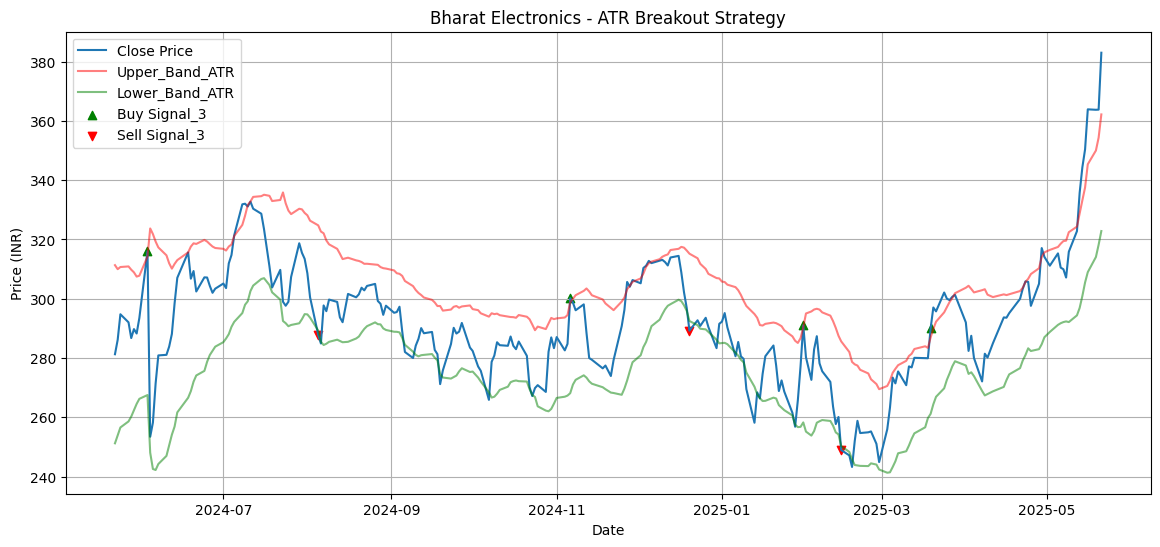

In [274]:
bharat['Signal_3'] = 0
bharat.loc[bharat["Close"] > bharat['Upper_Band_ATR'], 'Signal_3'] = 1
bharat.loc[bharat["Close"] < bharat['Lower_Band_ATR'], 'Signal_3'] = -1

last_signal = 0
for i in range(len(bharat)):
    current = bharat.loc[bharat.index[i], 'Signal_3']
    if current != 0:
        if current == last_signal:
            bharat.loc[bharat.index[i], 'Signal_3'] = 0
        else:
            last_signal = current

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(bharat.index, bharat["Close"], label='Close Price')
plt.plot(bharat.index, bharat['Upper_Band_ATR'], label='Upper_Band_ATR', color='red', alpha=0.5)
plt.plot(bharat.index, bharat['Lower_Band_ATR'], label='Lower_Band_ATR', color='green', alpha=0.5)
plt.scatter(bharat[bharat['Signal_3'] == 1].index, bharat[bharat['Signal_3'] == 1]["Close"], label='Buy Signal_3', marker='^', color='green')
plt.scatter(bharat[bharat['Signal_3'] == -1].index, bharat[bharat['Signal_3'] == -1]["Close"], label='Sell Signal_3', marker='v', color='red')
plt.title('Bharat Electronics - ATR Breakout Strategy')
plt.xlabel("Date")
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()


# **Backtesting**

Used trailing stop loss

In [275]:
# def capital(data, trade_index):
#     capt = [1000000]
#     k = 0
#     nia = 1000000
#     quantity = 0

#     for i in range(len(data)-1):
#         if k < len(trade_index) and i == trade_index[k]:

#             if data['Signal_1'].iloc[i] == 1:
#                 quantity = int(nia / data["Close"].iloc[i])
#                 nia -= quantity * data["Close"].iloc[i]
#                 capt.append(nia)
#             elif data['Signal_1'].iloc[i] == -1:
#                 nia += quantity * data["Close"].iloc[i]
#                 quantity = 0
#                 capt.append(nia)
#             k += 1
#         else:

#             capt.append(nia + quantity * data["Close"].iloc[i])

#     data['Capital'] = capt
#     return data
def capital_with_trailing_stoploss(data, trade_index, signal_col, stop_loss_pct, initial_capital=1_000_000):
    capital = initial_capital
    quantity = 0
    holding = False
    max_price = 0

    capt = []
    shares_list = []

    opening_trade_idx = []
    closing_trade_idx = []
    entry_date = []
    exit_date = []
    type_of_trade = []
    returns = []
    trade_quantity = []

    k = 0

    for i in range(len(data)):
        price = data['Close'].iloc[i]
        signal = data[signal_col].iloc[i]

        if k < len(trade_index) and i == trade_index[k]:
            if signal == 1 and not holding:
                quantity = int(capital / price)
                capital -= quantity * price
                max_price = price
                holding = True

                opening_trade_idx.append(i)
                entry_date.append(data.index[i])
                type_of_trade.append('long')
                trade_quantity.append(quantity)

            elif signal == -1 and holding:
                capital += quantity * price
                holding = False

                closing_trade_idx.append(i)
                exit_date.append(data.index[i])
                ret = ((price - data['Close'].iloc[opening_trade_idx[-1]]) * 100) / data['Close'].iloc[opening_trade_idx[-1]]
                returns.append(ret)

                quantity = 0

            k += 1

        # Trailing stop check
        if holding:
            max_price = max(max_price, price)
            if price < max_price * (1 - stop_loss_pct):
                capital += quantity * price
                holding = False

                closing_trade_idx.append(i)
                exit_date.append(data.index[i])
                ret = ((price - data['Close'].iloc[opening_trade_idx[-1]]) * 100) / data['Close'].iloc[opening_trade_idx[-1]]
                returns.append(ret)

                quantity = 0

        # Updating daily portfolio
        portfolio_value = capital + quantity * price
        capt.append(portfolio_value)
        shares_list.append(quantity)

    # square-off at end of trade
    if holding:
        final_price = data['Close'].iloc[-1]
        capital += quantity * final_price

        closing_trade_idx.append(len(data) - 1)
        exit_date.append(data.index[-1])
        ret = ((final_price - data['Close'].iloc[opening_trade_idx[-1]]) * 100) / data['Close'].iloc[opening_trade_idx[-1]]
        returns.append(ret)

        quantity = 0
        holding = False

        capt[-1] = capital
        shares_list[-1] = 0

    # Pad values to match data length
    if len(capt) < len(data):
        last_val = capt[-1]
        capt += [last_val] * (len(data) - len(capt))
        shares_list += [0] * (len(data) - len(shares_list))

    daily_df = pd.DataFrame({
        'Portfolio Value': capt,
        'No. of Stock': shares_list
    }, index=data.index)

    daily_df['Profit from Initial Capital (%)'] = (daily_df['Portfolio Value'] - initial_capital) * 100 / initial_capital
    daily_df['Daily Returns (%)'] = daily_df['Portfolio Value'].pct_change() * 100

    trade_wise_df = pd.DataFrame({
        'Entry Index': opening_trade_idx,
        'Exit Index': closing_trade_idx,
        'Entry Date': entry_date,
        'Exit Date': exit_date,
        'Type of Trade': type_of_trade,
        'No of stock traded': trade_quantity,
        'Return for trade in %': returns,
        'Trade Duration': [e - s for s, e in zip(opening_trade_idx, closing_trade_idx)]
    })

    return trade_wise_df, daily_df



In [316]:
trade_index = []
for i in range(len(adani)):
    if adani['Signal_2'].iloc[i] == 1 or adani['Signal_2'].iloc[i] == -1:
        trade_index.append(i)

adani_trade, adani_det= capital_with_trailing_stoploss(adani, trade_index, "Signal_2", 0.001)
adani_det

,Portfolio Value,No. of Stock,Profit from Initial Capital (%),Daily Returns (%)
Date,,,,
2024-05-22,1.000000e+06,0,0.000000,NaN
2024-05-23,1.000000e+06,0,0.000000,0.000000
2024-05-24,1.000000e+06,0,0.000000,0.000000
2024-05-27,1.000000e+06,0,0.000000,0.000000
2024-05-28,1.000000e+06,0,0.000000,0.000000
...,...,...,...,...
2025-05-15,1.109798e+06,1146,10.979824,0.067168
2025-05-16,1.169619e+06,1146,16.961939,5.390272
2025-05-19,1.162629e+06,0,16.262881,-0.597679


In [318]:
trade_index = []
for i in range(len(bharat)):
    if bharat['Signal_1'].iloc[i] == 1 or bharat['Signal_1'].iloc[i] == -1:
        trade_index.append(i)

bharat_trade, bharat_det = capital_with_trailing_stoploss(bharat, trade_index, "Signal_1", 0.05)

bharat_det

,Portfolio Value,No. of Stock,Profit from Initial Capital (%),Daily Returns (%)
Date,,,,
2024-05-22,1.000000e+06,0,0.000000,NaN
2024-05-23,1.000000e+06,0,0.000000,0.000000
2024-05-24,1.000000e+06,0,0.000000,0.000000
2024-05-27,1.000000e+06,0,0.000000,0.000000
2024-05-28,1.000000e+06,0,0.000000,0.000000
...,...,...,...,...
2025-05-15,1.368220e+06,3904,36.822039,1.756592
2025-05-16,1.420924e+06,3904,42.092439,3.852011
2025-05-19,1.420339e+06,3904,42.033882,-0.041211


In [293]:
def print_metrics(trade_wise_df, daily_df, benchmark_close):
    # Benchmark Return
    benchmark_return = ((benchmark_close[-1] - benchmark_close[0]) * 100) / benchmark_close[0]

    # Gross Profit
    gross_profit = daily_df["Profit from Initial Capital (%)"].iloc[-1]


    # Max & Avg Holding Time
    max_holding_time = trade_wise_df['Trade Duration'].max()
    avg_holding_time = trade_wise_df['Trade Duration'].mean()

    total_trades = len(trade_wise_df)
    winning_trades = (trade_wise_df['Return for trade in %'] > 0).sum()
    losing_trades = (trade_wise_df['Return for trade in %'] <= 0).sum()

    portfolio = daily_df['Portfolio Value']
    roll_max = portfolio.cummax()
    drawdown = (roll_max - portfolio) / roll_max
    max_drawdown = drawdown.max() * 100

    # Sharpe Ratio (Annualized)
    daily_returns = daily_df['Daily Returns (%)'] / 100
    sharpe_daily = daily_returns.mean() / daily_returns.std()
    sharpe_annualized = sharpe_daily * np.sqrt(252)

    # Print metrics
    print("Benchmark Return: " + str(round(benchmark_return, 2)) + " %")
    print("Gross Profit: " + str(round(gross_profit, 2)) + " %")
    print("Max Holding Time: " + str(max_holding_time))
    print("Average Holding Time: " + str(avg_holding_time))
    print("Total Trades: " + str(total_trades))
    print("Winning Trades: " + str(winning_trades))
    print("Losing Trades: " + str(losing_trades))
    print("Max Drawdown: " + str(round(max_drawdown, 2)) + " %")
    print("Sharpe Ratio (annualized): " + str(round(sharpe_annualized, 2)))
    print("Sharpe Ratio (daily): " + str(round(sharpe_daily, 4)))

In [294]:
print("METRICS : ADANI GREEN\n")
print_metrics(adani_trade, adani_det, adani['Close'])

METRICS : ADANI GREEN

Benchmark Return: -46.61 %
Gross Profit: 7.64 %
Max Holding Time: 7
Average Holding Time: 4.166666666666667
Total Trades: 6
Winning Trades: 4
Losing Trades: 2
Max Drawdown: 5.3 %
Sharpe Ratio (annualized): 0.79
Sharpe Ratio (daily): 0.0495


<ipython-input-293-83b324ed6b70>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  benchmark_return = ((benchmark_close[-1] - benchmark_close[0]) * 100) / benchmark_close[0]


In [295]:
print("METRICS : BHARAT ELECTRONICS\n")
print_metrics(bharat_trade, bharat_det, bharat['Close'])

METRICS : BHARAT ELECTRONICS

Benchmark Return: 36.17 %
Gross Profit: 49.55 %
Max Holding Time: 27
Average Holding Time: 9.923076923076923
Total Trades: 13
Winning Trades: 4
Losing Trades: 9
Max Drawdown: 14.85 %
Sharpe Ratio (annualized): 1.97
Sharpe Ratio (daily): 0.1241


<ipython-input-293-83b324ed6b70>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  benchmark_return = ((benchmark_close[-1] - benchmark_close[0]) * 100) / benchmark_close[0]


# **PART II**

In [296]:
vix = pd.read_csv("hist_india_vix_-22-05-2024-to-22-05-2025.csv")
vix.set_index("Date ", inplace=True)
vix

,Open,High,Low,Close,Prev. Close,Change,% Change
Date,,,,,,,
22-MAY-2024,21.8100,22.2925,18.1850,21.4675,21.8100,-0.34,-1.57
23-MAY-2024,21.4675,24.2150,18.8400,21.3800,21.4675,-0.09,-0.41
24-MAY-2024,21.3800,21.8975,20.5900,21.7100,21.3800,0.33,1.54
27-MAY-2024,21.7100,26.1950,18.4350,23.1925,21.7100,1.48,6.83
28-MAY-2024,23.1925,24.4750,22.0250,24.1950,23.1925,1.00,4.32
...,...,...,...,...,...,...,...
15-MAY-2025,17.2250,17.6725,16.7200,16.8900,17.2250,-0.34,-1.94
16-MAY-2025,16.8925,17.0550,16.2150,16.5500,16.8925,-0.34,-2.03
19-MAY-2025,16.5500,17.4475,15.8275,17.3600,16.5500,0.81,4.89


In [297]:
vix_mean = vix["Close "].mean()
vix_std = vix["Close "].std()

print("Mean:", vix_mean)
print("Standard Deviation:", vix_std)

Mean: 15.119274193548387
Standard Deviation: 2.5080443809512634


In [298]:
vix["Threshold_1"]=vix["Close "].mean()+0.5*vix["Close "].std()
vix["Threshold_2"]=vix["Close "].mean()+1.5*vix["Close "].std()

In [308]:
def capital_with_trailing_stoploss_VIX(data, trade_index, vix, signal_col, stop_loss_pct, initial_capital=1_000_000):
    capital = initial_capital
    quantity = 0
    holding = False
    max_price = 0

    capt = []
    shares_list = []

    opening_trade_idx = []
    closing_trade_idx = []
    entry_date = []
    exit_date = []
    type_of_trade = []
    returns = []
    trade_quantity = []

    k = 0

    # Step 1: Calculate threshold level from VIX
    threshold_level = []
    for i in range(len(vix)):
        close = vix.iloc[i]["Close "]
        t1 = vix.iloc[i]["Threshold_1"]
        t2 = vix.iloc[i]["Threshold_2"]
        if close < t1:
            threshold_level.append(0)
        elif close < t2:
            threshold_level.append(1)
        else:
            threshold_level.append(2)

    for i in range(len(data)):
        price = data['Close'].iloc[i]
        signal = data[signal_col].iloc[i]

        # Step 2: Adjust capital_to_use based on VIX level
        vix_level = threshold_level[i]
        if vix_level == 0:
            capital_to_use = capital
        elif vix_level == 1:
            capital_to_use = capital * 0.75
        else:
            capital_to_use = capital * 0.5

        if k < len(trade_index) and i == trade_index[k]:
            if signal == 1 and not holding:
                quantity = int(capital_to_use / price)
                capital -= quantity * price
                max_price = price
                holding = True

                opening_trade_idx.append(i)
                entry_date.append(data.index[i])
                type_of_trade.append('long')
                trade_quantity.append(quantity)

            elif signal == -1 and holding:
                capital += quantity * price
                holding = False

                closing_trade_idx.append(i)
                exit_date.append(data.index[i])
                ret = ((price - data['Close'].iloc[opening_trade_idx[-1]]) * 100) / data['Close'].iloc[opening_trade_idx[-1]]
                returns.append(ret)

                quantity = 0

            k += 1

        # Trailing stop check
        if holding:
            max_price = max(max_price, price)
            if price < max_price * (1 - stop_loss_pct):
                capital += quantity * price
                holding = False

                closing_trade_idx.append(i)
                exit_date.append(data.index[i])
                ret = ((price - data['Close'].iloc[opening_trade_idx[-1]]) * 100) / data['Close'].iloc[opening_trade_idx[-1]]
                returns.append(ret)

                quantity = 0

        # Updating daily portfolio
        portfolio_value = capital + quantity * price
        capt.append(portfolio_value)
        shares_list.append(quantity)

    # Final square-off
    if holding:
        final_price = data['Close'].iloc[-1]
        capital += quantity * final_price

        closing_trade_idx.append(len(data) - 1)
        exit_date.append(data.index[-1])
        ret = ((final_price - data['Close'].iloc[opening_trade_idx[-1]]) * 100) / data['Close'].iloc[opening_trade_idx[-1]]
        returns.append(ret)

        quantity = 0
        holding = False

        capt[-1] = capital
        shares_list[-1] = 0

    # Pad values to match data length
    if len(capt) < len(data):
        last_val = capt[-1]
        capt += [last_val] * (len(data) - len(capt))
        shares_list += [0] * (len(data) - len(shares_list))

    # Daily DataFrame
    daily_df = pd.DataFrame({
        'Portfolio Value': capt,
        'No. of Stock': shares_list
    }, index=data.index)

    daily_df['Profit from Initial Capital (%)'] = (daily_df['Portfolio Value'] - initial_capital) * 100 / initial_capital
    daily_df['Daily Returns (%)'] = daily_df['Portfolio Value'].pct_change() * 100

    # Trade Summary DataFrame
    trade_wise_df = pd.DataFrame({
        'Entry Index': opening_trade_idx,
        'Exit Index': closing_trade_idx,
        'Entry Date': entry_date,
        'Exit Date': exit_date,
        'Type of Trade': type_of_trade,
        'No of stock traded': trade_quantity,
        'Return for trade in %': returns,
        'Trade Duration': [e - s for s, e in zip(opening_trade_idx, closing_trade_idx)]
    })

    return trade_wise_df, daily_df


In [315]:
trade_index = []
for i in range(len(adani)):
    if adani['Signal_2'].iloc[i] == 1 or adani['Signal_2'].iloc[i] == -1:
        trade_index.append(i)

adani_trade_vix, adani_det_vix= capital_with_trailing_stoploss_VIX(adani, trade_index,vix,"Signal_2",0.001)
adani_det_vix

,Portfolio Value,No. of Stock,Profit from Initial Capital (%),Daily Returns (%)
Date,,,,
2024-05-22,1.000000e+06,0,0.000000,NaN
2024-05-23,1.000000e+06,0,0.000000,0.000000
2024-05-24,1.000000e+06,0,0.000000,0.000000
2024-05-27,1.000000e+06,0,0.000000,0.000000
2024-05-28,1.000000e+06,0,0.000000,0.000000
...,...,...,...,...
2025-05-15,1.109612e+06,859,10.961169,0.050347
2025-05-16,1.154451e+06,859,15.445144,4.041032
2025-05-19,1.149212e+06,0,14.921156,-0.453885


In [317]:
trade_index = []
for i in range(len(bharat)):
    if bharat['Signal_1'].iloc[i] == 1 or bharat['Signal_1'].iloc[i] == -1:
        trade_index.append(i)

bharat_trade_vix, bharat_det_vix = capital_with_trailing_stoploss_VIX(bharat, trade_index,vix,"Signal_1",0.05)

bharat_det_vix

,Portfolio Value,No. of Stock,Profit from Initial Capital (%),Daily Returns (%)
Date,,,,
2024-05-22,1.000000e+06,0,0.000000,NaN
2024-05-23,1.000000e+06,0,0.000000,0.000000
2024-05-24,1.000000e+06,0,0.000000,0.000000
2024-05-27,1.000000e+06,0,0.000000,0.000000
2024-05-28,1.000000e+06,0,0.000000,0.000000
...,...,...,...,...
2025-05-15,1.215646e+06,1913,21.564591,0.961207
2025-05-16,1.241471e+06,1913,24.147141,2.124426
2025-05-19,1.241184e+06,1913,24.118447,-0.023113


In [323]:
def print_var_cvar(daily_df, val):
    returns = daily_df['Daily Returns (%)'].dropna() / 100
    var = np.percentile(returns, 100 * (1-val))
    cvar = returns[returns <= var].mean()

    print(f"VaR: {var * 100} %")
    print(f"CVaR: {cvar * 100} %")

In [324]:
print("METRICS : ADANI GREEN(VIX)\n")
print_metrics(adani_trade_vix, adani_det_vix, adani['Close'])
print_var_cvar(adani_det_vix, 0.95)

METRICS : ADANI GREEN(VIX)

Benchmark Return: -46.61 %
Gross Profit: 14.92 %
Max Holding Time: 5
Average Holding Time: 3.0
Total Trades: 6
Winning Trades: 3
Losing Trades: 3
Max Drawdown: 1.35 %
Sharpe Ratio (annualized): 2.11
Sharpe Ratio (daily): 0.1328
VaR: 0.0 %
CVaR: -0.014419145576347001 %


<ipython-input-293-83b324ed6b70>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  benchmark_return = ((benchmark_close[-1] - benchmark_close[0]) * 100) / benchmark_close[0]


In [325]:
print("METRICS : BHARAT ELECTRONICS(VIX)\n")
print_metrics(bharat_trade_vix, bharat_det_vix, bharat['Close'])
print_var_cvar(bharat_det_vix, 0.95)

METRICS : BHARAT ELECTRONICS(VIX)

Benchmark Return: 36.17 %
Gross Profit: 27.8 %
Max Holding Time: 27
Average Holding Time: 9.923076923076923
Total Trades: 13
Winning Trades: 4
Losing Trades: 9
Max Drawdown: 13.18 %
Sharpe Ratio (annualized): 1.45
Sharpe Ratio (daily): 0.0916
VaR: -1.8549981072831987 %
CVaR: -2.696339244930894 %


<ipython-input-293-83b324ed6b70>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  benchmark_return = ((benchmark_close[-1] - benchmark_close[0]) * 100) / benchmark_close[0]
